In [1]:
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.activations import gelu
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
(X_train,_),(X_test,_)=mnist.load_data()

X_train=X_train.astype("float32")/255.0
X_test=X_test.astype("float32")/255.0
print(X_train.shape)
print(X_test.shape)



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [3]:
#create noisy_data solution 1
def transform(data,noise_factor=0.2):
  noisy_data=np.clip(data+np.random.normal(0,1,data.shape)*noise_factor,0,1)
  return noisy_data

#create noisy_data solution 2
#def transform(data,noise_factor=0.2):
  # noisy_data=np.clip(data+np.random.normal(loc=0,scale=1,size=data.shape)*noise_factor,0,1)
  # return noisy_data


0.0 1.0


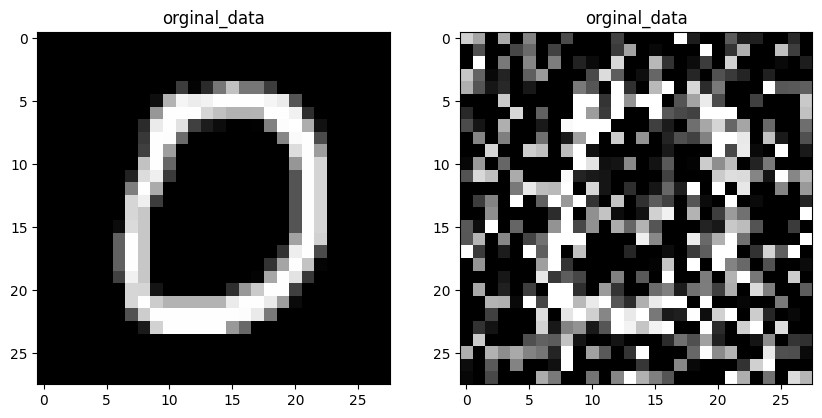

In [4]:
X_train_noisy=transform(X_train,0.6)
X_test_noisy=transform(X_test,0.6)

print(X_train_noisy.min(),X_train_noisy.max())
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.imshow(X_test[10],cmap="gray")
plt.title("orginal_data")
plt.subplot(1,2,2)
plt.imshow(X_test_noisy[10],cmap="gray")
plt.title("orginal_data")
plt.show()


In [5]:
width,height,channel=28,28,1
#encoder
inputs=layers.Input(shape=(width,height,channel))

conv_1=layers.Conv2D(32,(3,3))(inputs)
batch_1=layers.BatchNormalization()(conv_1)
leaky_1=layers.LeakyReLU()(batch_1)

conv_2=layers.Conv2D(32,(3,3))(leaky_1)
batch_2=layers.BatchNormalization()(conv_2)
leaky_2=layers.LeakyReLU()(batch_2)


conv_3=layers.Conv2D(64,(3,3))(leaky_2)
batch_3=layers.BatchNormalization()(conv_3)
leaky_3=layers.LeakyReLU()(batch_3)

conv_4=layers.Conv2D(64,(3,3))(leaky_3)
batch_4=layers.BatchNormalization()(conv_4)
leaky_4=layers.LeakyReLU()(batch_4)


conv_5=layers.Conv2D(128,(3,3))(leaky_4)
batch_5=layers.BatchNormalization()(conv_5)
leaky_5=layers.LeakyReLU()(batch_5)

conv_6=layers.Conv2D(128,(3,3))(leaky_5)
batch_6=layers.BatchNormalization()(conv_6)
leaky_6=layers.LeakyReLU()(batch_6)


#decoder
deconv_1=layers.Conv2DTranspose(128,(3,3))(leaky_6)
debatch_1=layers.BatchNormalization()(deconv_1)
deleaky_1=layers.LeakyReLU()(debatch_1)

deconv_2=layers.Conv2DTranspose(128,(3,3))(deleaky_1)
debatch_2=layers.BatchNormalization()(deconv_2)
deleaky_2=layers.LeakyReLU()(debatch_2)

deconv_3=layers.Conv2DTranspose(128,(3,3))(deleaky_2)
debatch_3=layers.BatchNormalization()(deconv_3)
deleaky_3=layers.LeakyReLU()(debatch_3)


deconv_4=layers.Conv2DTranspose(64,(3,3))(deleaky_3)
debatch_4=layers.BatchNormalization()(deconv_4)
deleaky_4=layers.LeakyReLU()(debatch_4)

deconv_5=layers.Conv2DTranspose(32,(3,3))(deleaky_4)
debatch_5=layers.BatchNormalization()(deconv_5)
deleaky_5=layers.LeakyReLU()(debatch_5)


deconv_6=layers.Conv2DTranspose(32,(3,3))(deleaky_5)
debatch_6=layers.BatchNormalization()(deconv_6)
deleaky_6=layers.LeakyReLU()(debatch_6)

outputs=layers.Conv2D(channel,(3,3),activation="sigmoid",padding="same")(deleaky_6)


autoencoder=Model(inputs=inputs,outputs=outputs)
autoencoder.summary()
autoencoder.compile(optimizer="adam",loss="mse",metrics=["mse"])



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 18, 18, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 834,817 (3.18 MB)

 Trainable params: 832,897 (3.18 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [6]:
autoencoder.fit(X_train_noisy,X_train,validation_split=0.1,validation_data=(X_test_noisy,X_test),epochs=20,batch_size=64)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 45ms/step - loss: 0.0218 - mse: 0.0218 - val_loss: 0.0137 - val_mse: 0.0137
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - loss: 0.0135 - mse: 0.0135 - val_loss: 0.0140 - val_mse: 0.0140
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 0.0129 - mse: 0.0129 - val_loss: 0.0137 - val_mse: 0.0137
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - loss: 0.0125 - mse: 0.0125 - val_loss: 0.0123 - val_mse: 0.0123
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - loss: 0.0122 - mse: 0.0122 - val_loss: 0.0124 - val_mse: 0.0124
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 0.0120 - mse: 0.0120 - val_loss: 0.0132 - val_mse: 0.0132
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 0.0119 - mse: 0.0119 - val_loss: 0.0120 - val_mse: 0.0120
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - loss: 0.0118 - mse: 0.0118 - val_loss: 0.0121 - val_mse: 0.0121
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 

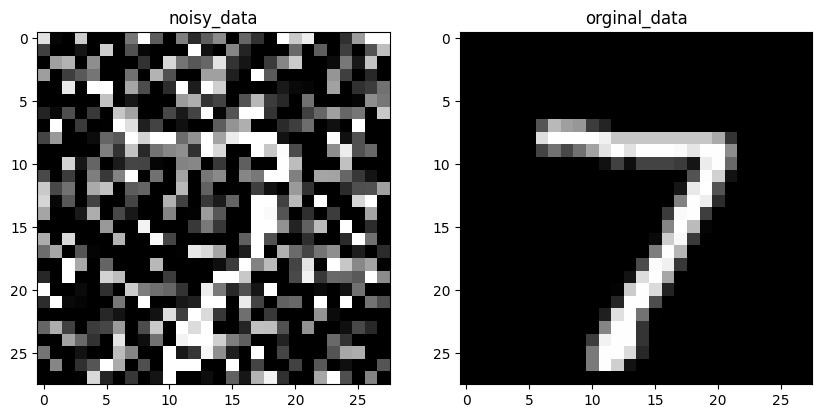

In [7]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.imshow(X_test_noisy[0],cmap="gray")
plt.title("noisy_data")
plt.subplot(1,2,2)
plt.imshow(X_test[0],cmap="gray")
plt.title("orginal_data")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


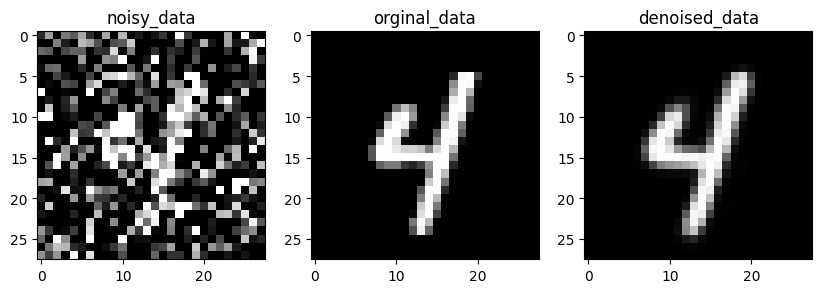

In [14]:
import random
n=random.sample(range(0,1000),1)
pred_prob=autoencoder.predict(X_test_noisy)

#Drawing a diagram
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
plt.imshow(X_test_noisy[n].reshape(28,28),cmap="gray")
plt.title("noisy_data")
plt.subplot(1,3,2)
plt.imshow(X_test[n].reshape(28,28),cmap="gray")
plt.title("orginal_data")
plt.subplot(1,3,3)
plt.imshow(pred_prob[n].reshape(28,28),cmap="gray")
plt.title("denoised_data")
plt.show()

In [22]:
from google.colab import files
uploaded=files.upload()

Saving 0.png to 0 (1).png


give me your img: 0 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


Text(0.5, 1.0, 'predict_number')

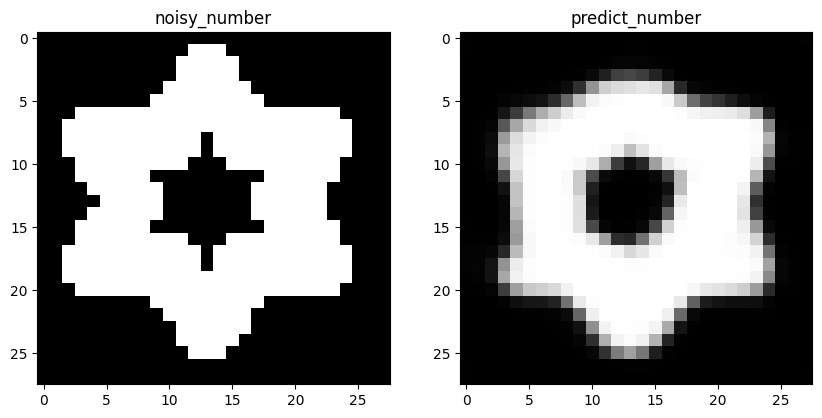

In [24]:


import cv2

img_path=input("give me your img: ")
img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE).astype("float32")/255.0


img=img.reshape(1,28,28)

pred_img=autoencoder.predict(img)

plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.imshow(img.reshape(28,28),cmap="gray")
plt.title("noisy_number")
plt.subplot(1,2,2)
plt.imshow(pred_img.reshape(28,28),cmap="gray")
plt.title("predict_number")



In [25]:
autoencoder_model=autoencoder.save("my_model.h5")
autoencoder_model